In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA


master_df=pd.read_csv("data/processed/master_player_features.csv")
master_df

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,age,goal_per90,assists_per90,goals_per90,card_per90,cards_per90,log_market_value,intl_goal_ratio,position_group,goal_contribution_per90
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,48,48.0,0.255450,0.490463,0.194142,0.194142,13.815512,NaN,Attack,0.745913
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,45,0.0,0.000000,0.000000,0.039976,0.039976,13.527830,NaN,Goalkeeper,0.000000
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,45,38.0,0.133136,0.389167,0.122895,0.122895,13.815512,NaN,Attack,0.522303
3,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,45,0.0,0.000000,0.000000,0.000000,0.000000,11.512935,NaN,Goalkeeper,0.000000
4,109,NaN,Dedê,Dedê,2013,825,dede,Brazil,Belo Horizonte,Brazil,...,48,1.0,0.050223,0.025112,0.100446,0.100446,12.899222,NaN,Defender,0.075335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17462,1360186,Barney,Stewart,Barney Stewart,2025,1191,barney-stewart,England,London,Scotland,...,22,10.0,0.125874,0.629371,0.062937,0.062937,NaN,0.000000,Attack,0.755245
17463,1364454,Christian,Kofane,Christian Kofane,2025,15,christian-kofane,Cameroon,Douala,Cameroon,...,19,7.0,0.408472,0.317700,0.226929,0.226929,NaN,0.285714,Attack,0.726172
17464,1380311,Prince,Amoako Junior,Prince Amoako Junior,2025,2778,prince-amoako-junior,Ghana,Amasaman,Ghana,...,19,7.0,0.237342,0.332278,0.047468,0.047468,NaN,NaN,Attack,0.569620
17465,1390649,Yan,Diomande,Yan Diomande,2025,23826,yan-diomande,Cote d'Ivoire,Abidjan,Cote d'Ivoire,...,19,16.0,0.273632,0.398010,0.099502,0.099502,17.622173,0.300000,Attack,0.671642


In [3]:
features=[
    "age",
    "goals_per90",
    "assists_per90",
    "cards_per90",
    "matches",
    "minutes_played",
    "log_market_value"
]

X=master_df[features]
X

,age,goals_per90,assists_per90,cards_per90,matches,minutes_played,log_market_value
0,48,0.490463,0.255450,0.194142,136.0,8808.0,13.815512
1,45,0.000000,0.000000,0.039976,152.0,13508.0,13.527830
2,45,0.389167,0.133136,0.122895,122.0,8788.0,13.815512
3,45,0.000000,0.000000,0.000000,12.0,1080.0,11.512935
4,48,0.025112,0.050223,0.100446,41.0,3584.0,12.899222
...,...,...,...,...,...,...,...
17462,22,0.629371,0.125874,0.062937,18.0,1430.0,NaN
17463,19,0.317700,0.408472,0.226929,44.0,1983.0,NaN
17464,19,0.332278,0.237342,0.047468,25.0,1896.0,NaN
17465,19,0.398010,0.273632,0.099502,51.0,3618.0,17.622173


In [4]:
X=X.fillna(0)
X


,age,goals_per90,assists_per90,cards_per90,matches,minutes_played,log_market_value
0,48,0.490463,0.255450,0.194142,136.0,8808.0,13.815512
1,45,0.000000,0.000000,0.039976,152.0,13508.0,13.527830
2,45,0.389167,0.133136,0.122895,122.0,8788.0,13.815512
3,45,0.000000,0.000000,0.000000,12.0,1080.0,11.512935
4,48,0.025112,0.050223,0.100446,41.0,3584.0,12.899222
...,...,...,...,...,...,...,...
17462,22,0.629371,0.125874,0.062937,18.0,1430.0,0.000000
17463,19,0.317700,0.408472,0.226929,44.0,1983.0,0.000000
17464,19,0.332278,0.237342,0.047468,25.0,1896.0,0.000000
17465,19,0.398010,0.273632,0.099502,51.0,3618.0,17.622173


In [5]:
scaler=StandardScaler()
Scaled_x=scaler.fit_transform(X)
Scaled_x

array([[ 2.33436393,  2.71434955,  1.94277315, ...,  0.34327759,
         0.22188347,  0.35168459],
       [ 1.88218161, -0.85165762, -1.04598053, ...,  0.51415942,
         0.8851122 ,  0.2516541 ],
       [ 1.88218161,  1.97785626,  0.51170837, ...,  0.19375599,
         0.21906122,  0.35168459],
       ...,
       [-2.03673182,  1.564237  ,  1.73091213, ..., -0.84221508,
        -0.75348612, -4.45213958],
       [-2.03673182,  2.0421503 ,  2.15550501, ..., -0.56453211,
        -0.5104904 ,  1.67530786],
       [-2.03673182,  0.58229924, -1.04598053, ..., -0.85289519,
        -0.8278524 ,  0.35168459]], shape=(17467, 7))

In [6]:
inertia=[]

for k in range(1,11):
    Kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    Kmeans.fit(Scaled_x)

    inertia.append(Kmeans.inertia_)

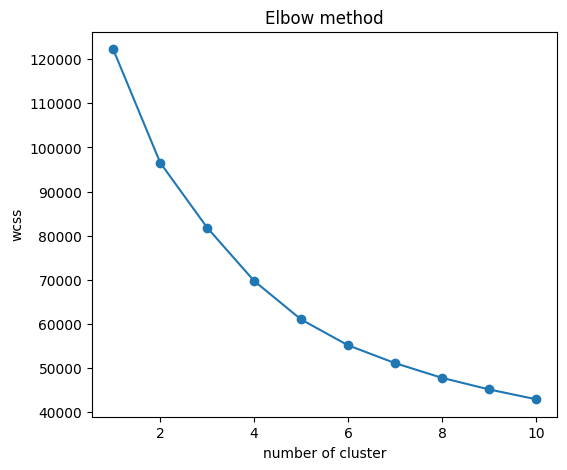

In [7]:
plt.figure(figsize=(6,5))

plt.plot(range(1,11),inertia,marker='o')
plt.xlabel('number of cluster')
plt.ylabel('wcss')
plt.title('Elbow method')
plt.show()

In [8]:
for k in range(2,11):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)

    labels=km.fit_predict(Scaled_x)

    score=silhouette_score(Scaled_x,labels)

    print(f"k={k} Score={score:.3f}")

k=2 Score=0.262
k=3 Score=0.222
k=4 Score=0.246
k=5 Score=0.209
k=6 Score=0.203
k=7 Score=0.200
k=8 Score=0.205
k=9 Score=0.208
k=10 Score=0.207


In [9]:
kmean=KMeans(n_clusters=5,random_state=42,n_init=10)

master_df['cluster']=(kmean.fit_predict(Scaled_x))


In [10]:
master_df['cluster'].value_counts()

cluster
1    5423
0    5239
4    3695
3    2517
2     593
Name: count, dtype: int64

In [11]:
cluster_profile = (
    master_df
    .groupby("cluster")
    [
        features
    ]
    .mean()
    .round(2)
)

cluster_profile

,age,goals_per90,assists_per90,cards_per90,matches,minutes_played,log_market_value
cluster,,,,,,,
0,38.81,0.05,0.05,0.23,68.03,5111.89,12.07
1,27.06,0.06,0.06,0.20,66.49,4487.30,13.79
2,24.36,0.13,0.09,0.19,28.68,1889.26,NaN
3,33.68,0.12,0.11,0.19,285.37,21136.92,14.25
4,32.10,0.29,0.18,0.18,97.92,5668.92,13.48


In [12]:
cluster_profile_min_max=(master_df.groupby('cluster')[features]).agg(['min','max'])
cluster_profile_min_max

age     goals_per90           assists_per90           cards_per90  \
        min max         min       max           min       max         min   
cluster                                                                     
0        30  55         0.0  0.433039           0.0  0.323741    0.000000   
1        17  35         0.0  0.438668           0.0  0.291892    0.000000   
2        17  37         0.0  0.815217           0.0  0.426829    0.000000   
3        22  48         0.0  0.944836           0.0  0.491108    0.005064   
4        18  52         0.0  1.096447           0.0  0.730388    0.000000   

                  matches        minutes_played          log_market_value  \
              max     min    max            min      max              min   
cluster                                                                     
0        0.902708    10.0  225.0          900.0  17746.0         9.210440   
1        0.830904     9.0  207.0          900.0  16127.0        10.126671   
2        0.775862    10.0   93.0          900.0   5817.0              NaN   
3        0.521081   163.0  665.0        10962.0  54203.0         9.210440   
4        0.667766    12.0  323.0          900.0  23546.0         9.210440   

                    
               max  
cluster             
0        15.607270  
1        18.515991  
2              NaN  
3        19.008467  
4        19.113828

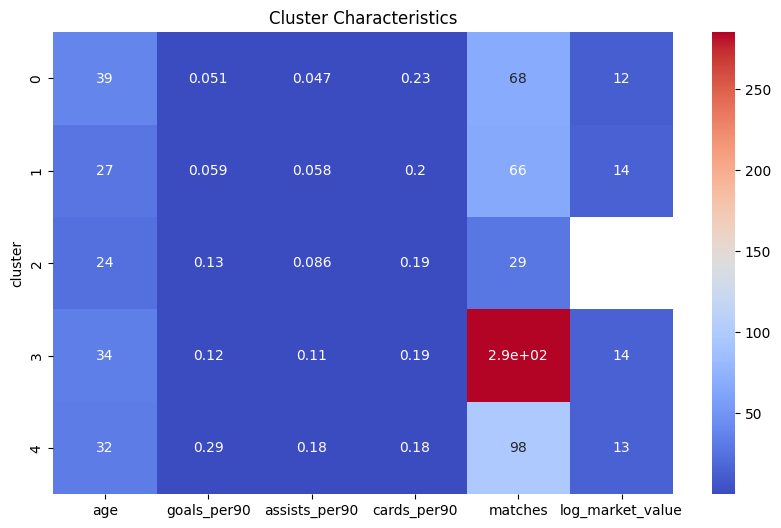

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_profile = (
    master_df
    .groupby("cluster")
    [
        [
            "age",
            "goals_per90",
            "assists_per90",
            "cards_per90",
            "matches",
            "log_market_value"
        ]
    ]
    .mean()
)

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="coolwarm"
)

plt.title("Cluster Characteristics")
plt.show()

In [14]:
silhouette_score(
    Scaled_x,
    master_df["cluster"]
)   

0.2085391568547114

In [15]:
cluster_names = {
    0: "Veterans",
    1: "Defensive Specialists",
    2: "Young Prospects",
    3: "Experienced Professionals",
    4: "Elite Attacks"
}


master_df['cluster_name']=master_df['cluster'].map(cluster_names)

master_df

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,assists_per90,goals_per90,card_per90,cards_per90,log_market_value,intl_goal_ratio,position_group,goal_contribution_per90,cluster,cluster_name
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,0.255450,0.490463,0.194142,0.194142,13.815512,NaN,Attack,0.745913,4,Elite Attacks
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,0.000000,0.000000,0.039976,0.039976,13.527830,NaN,Goalkeeper,0.000000,0,Veterans
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,0.133136,0.389167,0.122895,0.122895,13.815512,NaN,Attack,0.522303,4,Elite Attacks
3,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,0.000000,0.000000,0.000000,0.000000,11.512935,NaN,Goalkeeper,0.000000,0,Veterans
4,109,NaN,Dedê,Dedê,2013,825,dede,Brazil,Belo Horizonte,Brazil,...,0.050223,0.025112,0.100446,0.100446,12.899222,NaN,Defender,0.075335,0,Veterans
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17462,1360186,Barney,Stewart,Barney Stewart,2025,1191,barney-stewart,England,London,Scotland,...,0.125874,0.629371,0.062937,0.062937,NaN,0.000000,Attack,0.755245,2,Young Prospects
17463,1364454,Christian,Kofane,Christian Kofane,2025,15,christian-kofane,Cameroon,Douala,Cameroon,...,0.408472,0.317700,0.226929,0.226929,NaN,0.285714,Attack,0.726172,2,Young Prospects
17464,1380311,Prince,Amoako Junior,Prince Amoako Junior,2025,2778,prince-amoako-junior,Ghana,Amasaman,Ghana,...,0.237342,0.332278,0.047468,0.047468,NaN,NaN,Attack,0.569620,2,Young Prospects
17465,1390649,Yan,Diomande,Yan Diomande,2025,23826,yan-diomande,Cote d'Ivoire,Abidjan,Cote d'Ivoire,...,0.273632,0.398010,0.099502,0.099502,17.622173,0.300000,Attack,0.671642,4,Elite Attacks


In [16]:
pca_score=PCA(n_components=2,random_state=42)
X_pca=pca_score.fit_transform(Scaled_x)

In [17]:
master_df['PC1']=X_pca[:,0]
master_df["PC2"]=X_pca[:,1]

In [18]:
import plotly.express as px

fig=px.scatter(master_df,x="PC1",y="PC2",color="cluster_name",hover_name='name',title='Player Style Clsuters')
fig.show()

In [19]:
for cluster in sorted(
    master_df["cluster"].unique()
):

    print("\n")
    print("="*50)

    print(
        f"Cluster {cluster}"
    )

    display(
        master_df[
            master_df["cluster"] == cluster
        ][
            [
                "name",
                "position_group",
                "goals",
                "assists",
                "market_value_in_eur"
            ]
        ]
        .sort_values(
            "market_value_in_eur",
            ascending=False
        )
        .head(20)
    )



Cluster 0


,name,position_group,goals,assists,market_value_in_eur
4354,Álvaro Domínguez,Defender,3.0,5.0,6000000.0
9127,Matheus Uribe,Midfield,13.0,6.0,5000000.0
1079,Marcell Jansen,Attack,4.0,10.0,4000000.0
1481,Daniel Agger,Defender,7.0,4.0,4000000.0
2843,Stefan Reinartz,Midfield,5.0,5.0,4000000.0
2103,Cheik Tioté,Midfield,0.0,5.0,3200000.0
144,Hugo Viana,Midfield,8.0,3.0,3000000.0
3492,Adilson,Midfield,3.0,3.0,2750000.0
790,Raúl Meireles,Midfield,8.0,10.0,2750000.0
1546,Lassana Diarra,Midfield,3.0,3.0,2500000.0




Cluster 1


,name,position_group,goals,assists,market_value_in_eur
15820,João Neves,Midfield,17.0,17.0,110000000.0
15737,Willian Pacho,Defender,2.0,5.0,70000000.0
16454,Aleksandar Pavlovic,Midfield,7.0,5.0,65000000.0
16562,Álvaro Carreras,Defender,7.0,8.0,60000000.0
16411,Pablo Barrios,Midfield,7.0,10.0,60000000.0
14828,Elliot Anderson,Midfield,6.0,14.0,60000000.0
15510,Alejandro Balde,Defender,3.0,21.0,60000000.0
16320,Adam Wharton,Midfield,1.0,11.0,60000000.0
17119,Carlos Baleba,Midfield,3.0,4.0,60000000.0
16962,Leny Yoro,Defender,4.0,3.0,55000000.0




Cluster 2


,name,position_group,goals,assists,market_value_in_eur
5113,Valentin Crețu,Defender,0.0,3.0,NaN
6458,Michal Frydrych,Defender,1.0,0.0,NaN
7220,Risto Radunovic,Defender,1.0,2.0,NaN
7533,Peter Michorl,Midfield,1.0,7.0,NaN
7672,Dénes Dibusz,Goalkeeper,0.0,0.0,NaN
8039,Jesús Imaz,Midfield,6.0,3.0,NaN
8135,Nikola Boranijasevic,Defender,0.0,0.0,NaN
8315,Fabricio Pedrozo,Attack,15.0,4.0,NaN
8324,Alexander Schlager,Goalkeeper,0.0,1.0,NaN
8388,Artem Bykov,Midfield,0.0,2.0,NaN




Cluster 3


,name,position_group,goals,assists,market_value_in_eur
12367,Vinicius Junior,Attack,120.0,98.0,180000000.0
11771,Kylian Mbappé,Attack,326.0,112.0,180000000.0
14996,Jude Bellingham,Midfield,70.0,58.0,160000000.0
12962,Phil Foden,Midfield,105.0,60.0,150000000.0
13300,Bukayo Saka,Attack,80.0,74.0,130000000.0
11945,Alexander Isak,Attack,123.0,27.0,120000000.0
12301,Federico Valverde,Midfield,41.0,44.0,120000000.0
12115,Declan Rice,Midfield,34.0,41.0,120000000.0
15937,Moisés Caicedo,Midfield,10.0,13.0,110000000.0
13026,Rodrygo,Attack,70.0,58.0,110000000.0




Cluster 4


,name,position_group,goals,assists,market_value_in_eur
13099,Erling Haaland,Attack,255.0,52.0,200000000.0
14813,Michael Olise,Attack,58.0,79.0,130000000.0
14977,Jamal Musiala,Midfield,69.0,45.0,130000000.0
17034,Lamine Yamal,Attack,49.0,52.0,120000000.0
14836,Cole Palmer,Midfield,59.0,31.0,120000000.0
15159,Florian Wirtz,Midfield,63.0,74.0,110000000.0
14937,Julián Álvarez,Attack,84.0,35.0,100000000.0
14117,Khvicha Kvaratskhelia,Attack,64.0,59.0,90000000.0
16927,Désiré Doué,Attack,32.0,28.0,90000000.0
16093,Hugo Ekitiké,Attack,56.0,28.0,85000000.0


In [20]:
cluster_profile = (
    master_df
    .groupby("cluster")
    [
        [
            "age",
            "goals_per90",
            "assists_per90",
            "goal_contribution_per90",
            "cards_per90",
            "matches",
            "market_value_in_eur"
        ]
    ]
    .mean()
    .round(2)
)

cluster_profile

,age,goals_per90,assists_per90,goal_contribution_per90,cards_per90,matches,market_value_in_eur
cluster,,,,,,,
0,38.81,0.05,0.05,0.10,0.23,68.03,266208.25
1,27.06,0.06,0.06,0.12,0.20,66.49,2804512.26
2,24.36,0.13,0.09,0.21,0.19,28.68,NaN
3,33.68,0.12,0.11,0.23,0.19,285.37,6802467.22
4,32.10,0.29,0.18,0.47,0.18,97.92,3421354.53


In [21]:
master_df.to_csv(
    "data/processed/clustered_players.csv",
    index=False
)

In [22]:
import pickle

pickle.dump(
    Kmeans,
    open(
        "models/kmeans_model.pkl",
        "wb"
    )
)

pickle.dump(
    scaler,
    open(
        "models/scaler.pkl",
        "wb"
    )
)

pickle.dump(
    pca_score,
    open(
        "models/pca.pkl",
        "wb"
    )
)